In [3]:
# Лабораторная работа №8 Горьков Антон 5130901/30201
# Глава 8. Фильтрация и свертка

In [4]:
#Упражнение 8.1
#Что случится, если при увеличении ширины гауссова окна std не увеличивать число элементов в окне м?

In [5]:
#Ответ: если увеличивать std без увеличения M, окно начинает сильно обрезаться, и его фильтрующие свойства ухудшаются.

In [11]:
import numpy as np
import matplotlib.pyplot as plt
import scipy.signal
from thinkdsp import decorate

In [8]:
# Упражнение 8.2
#
# В этой главе утверждается, что преобразование Фурье гауссовой
# кривой — также гауссова кривая. Для дискретного преобразования
# Фурье это соотношение приблизительно верно.
#
# Попробуйте его на нескольких примерах.
# Что происходит с преобразованием Фурье, если меняется std?

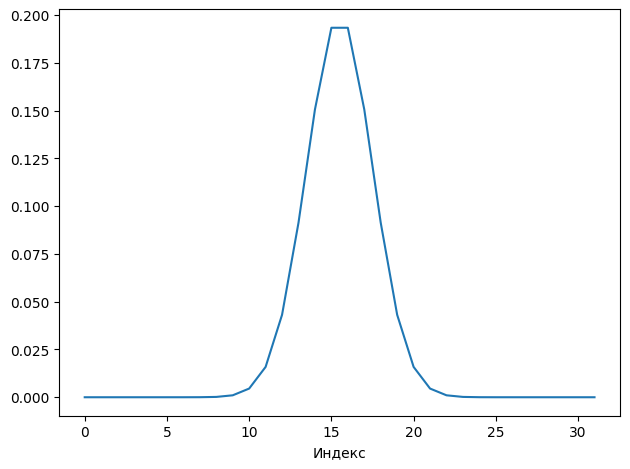

In [14]:
# Начнем с одного примера гауссовой кривой.
M = 32
std = 2

gaussian = scipy.signal.windows.gaussian(M=M, std=std)
gaussian /= sum(gaussian)

plt.plot(gaussian)
decorate(xlabel='Индекс')

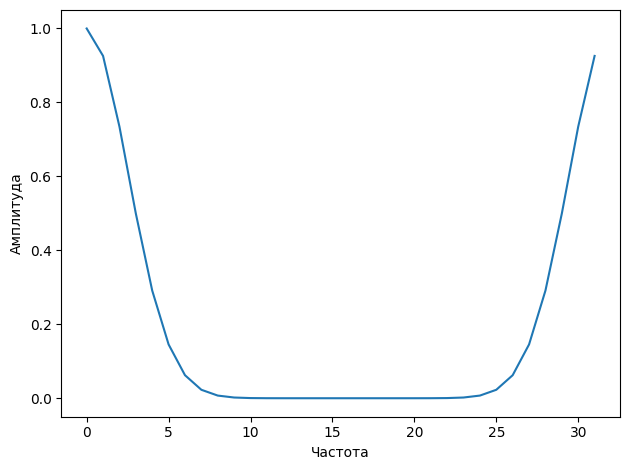

In [15]:
# Вычислим ее быстрое преобразование Фурье.

fft_gaussian = np.fft.fft(gaussian)
plt.plot(np.abs(fft_gaussian))
decorate(xlabel='Частота', ylabel='Амплитуда')

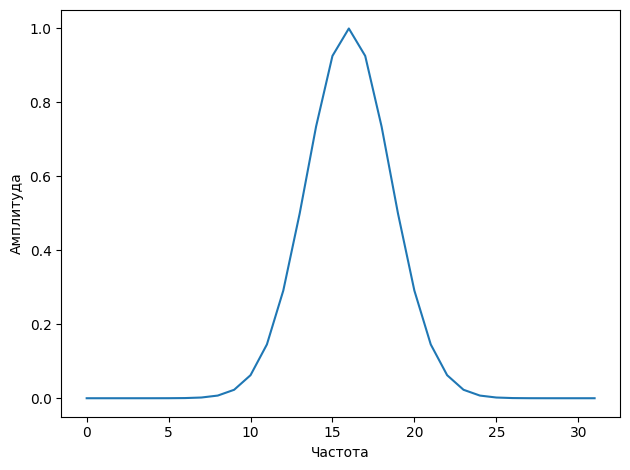

In [16]:
# Сдвинем спектр так, чтобы нулевая частота оказалась в центре.

fft_rolled = np.roll(fft_gaussian, M//2)
plt.plot(np.abs(fft_rolled))
decorate(xlabel='Частота', ylabel='Амплитуда')

In [38]:
# Эта функция строит гауссову кривую и ее спектр
# для заданного значения std.

def plot_gaussian(std):
    M = 32
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    gaussian /= sum(gaussian)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(gaussian)
    decorate(xlabel='Время')
    
    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, M//2)
    
    plt.subplot(1, 2, 2)
    plt.plot(np.abs(fft_rolled))
    decorate(xlabel='Частота')
    
    plt.show()

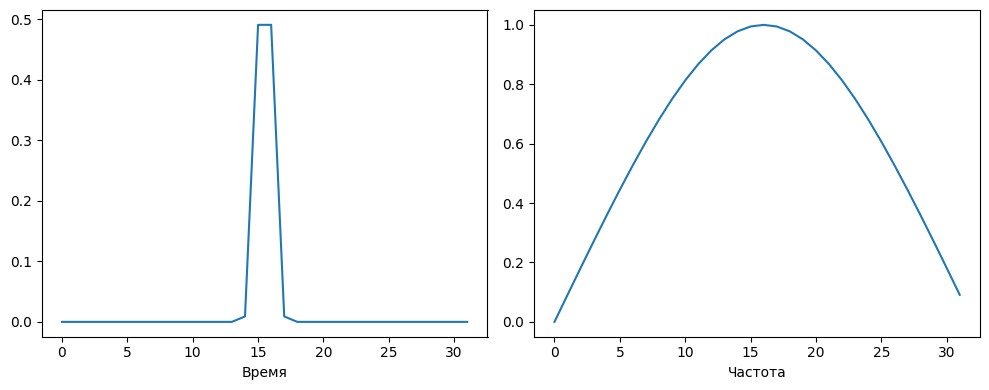

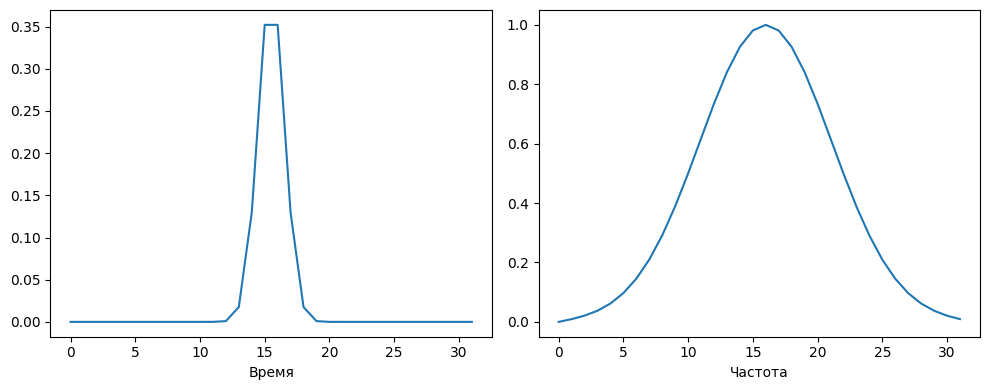

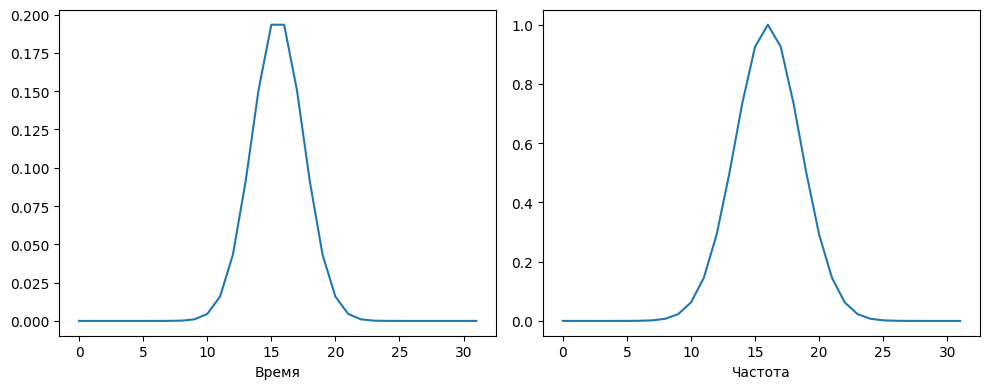

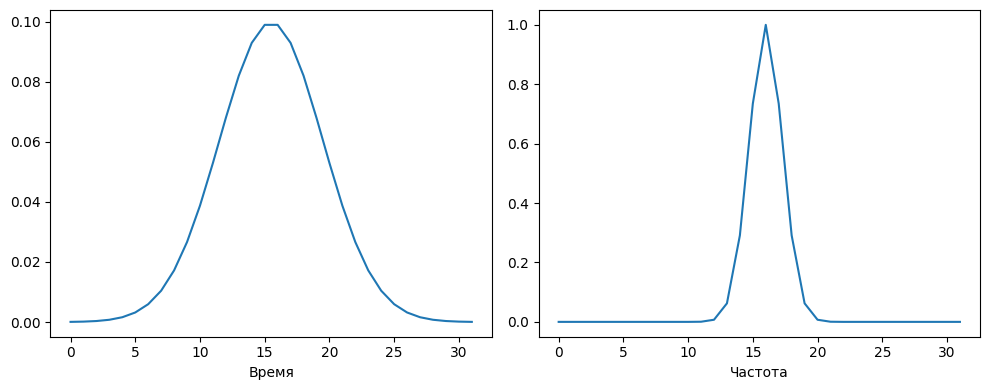

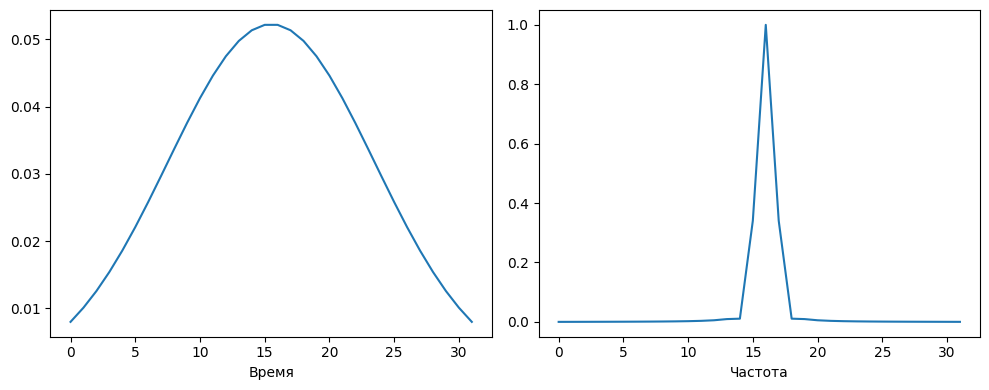

In [39]:
# Проверим несколько значений std.

for std in [0.5, 1, 2, 4, 8]:
    plot_gaussian(std)

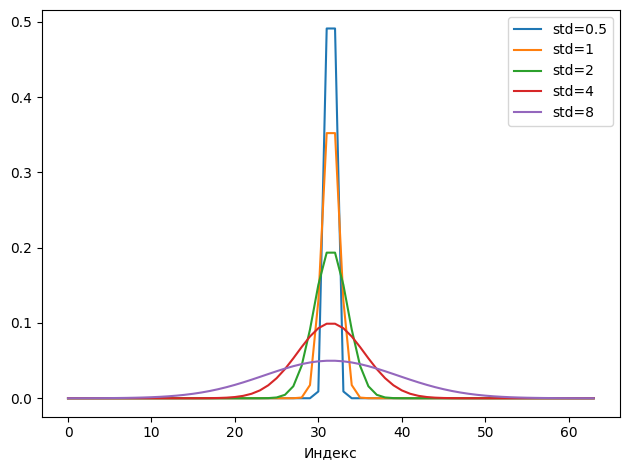

In [19]:
# Наложим несколько гауссовых кривых на один график.

for std in [0.5, 1, 2, 4, 8]:
    gaussian = scipy.signal.windows.gaussian(M=64, std=std)
    gaussian /= sum(gaussian)
    plt.plot(gaussian, label='std=%g' % std)

decorate(xlabel='Индекс')
plt.legend()

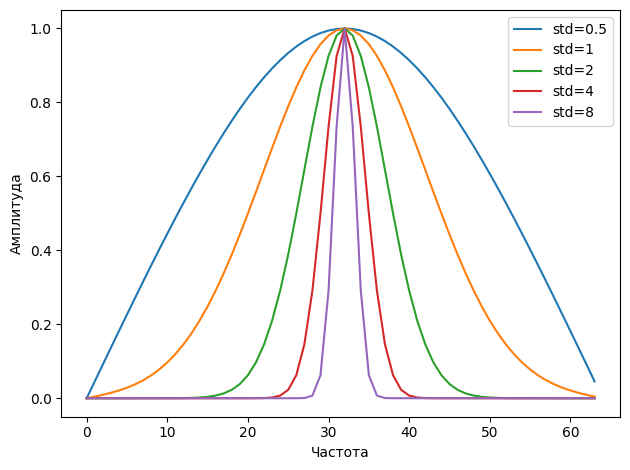

In [20]:
# И наложим их спектры.

for std in [0.5, 1, 2, 4, 8]:
    gaussian = scipy.signal.windows.gaussian(M=64, std=std)
    gaussian /= sum(gaussian)
    
    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, len(gaussian)//2)
    
    plt.plot(np.abs(fft_rolled), label='std=%g' % std)

decorate(xlabel='Частота', ylabel='Амплитуда')
plt.legend()

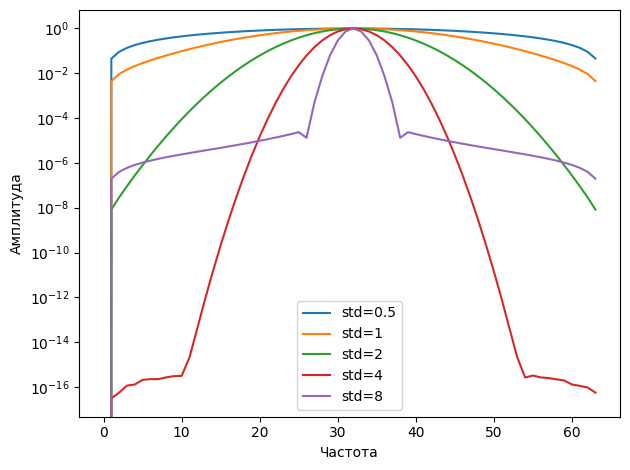

In [21]:
# То же самое в логарифмическом масштабе по оси амплитуды.

for std in [0.5, 1, 2, 4, 8]:
    gaussian = scipy.signal.windows.gaussian(M=64, std=std)
    gaussian /= sum(gaussian)
    
    fft_gaussian = np.fft.fft(gaussian)
    fft_rolled = np.roll(fft_gaussian, len(gaussian)//2)
    
    plt.plot(np.abs(fft_rolled), label='std=%g' % std)

decorate(xlabel='Частота', ylabel='Амплитуда', yscale='log')
plt.legend()

In [22]:
# Выводы:
# 1. В дискретном случае преобразование Фурье гауссовой кривой
#    действительно похоже на гауссову кривую.
# 2. Если std увеличивается, исходная гауссова кривая становится шире.
# 3. При этом ее спектр становится уже.
# 4. Если std уменьшается, исходная кривая сужается,
#    а ее спектр расширяется.
# 5. Значит, ширина гауссовой кривой и ширина ее спектра
#    связаны обратным соотношением.

In [23]:
# Упражнение 8.3
#
# В упражнениях к главе 3 изучалось влияние на утечки спектра окна
# Хэмминга и некоторых других окон, предоставляемых NumPy.
# Глубже понять эти окна можно, изучив их ДПФ.
#
# В дополнение к гауссову окну, использованному в этой главе,
# создайте окно Хэмминга тех же размеров. Дополните окно нулями
# и напечатайте его ДПФ.
#
# Какое окно больше подходит для фильтра НЧ?
# Полезно напечатать ДПФ с логарифмическим масштабом по y.
#
# Поэкспериментируйте с разными окнами и разными размерами.

In [24]:
# Начнем с двух окон одинакового размера.

M = 32
std = 5

gaussian = scipy.signal.windows.gaussian(M=M, std=std)
hamming = np.hamming(M)

In [25]:
# Нормализуем окна, чтобы их было удобнее сравнивать.

gaussian /= sum(gaussian)
hamming /= sum(hamming)

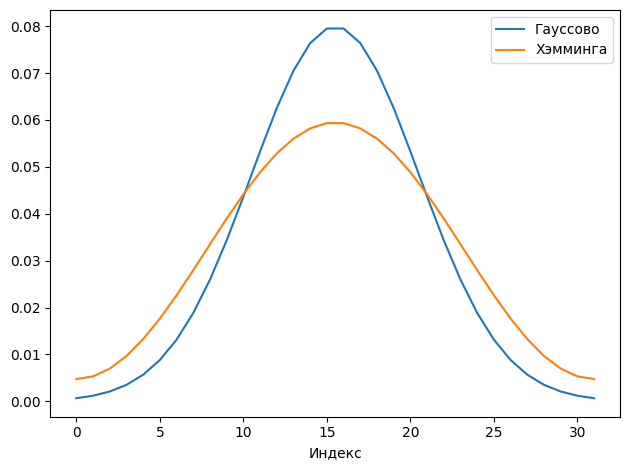

In [26]:
# Посмотрим на сами окна.

plt.plot(gaussian, label='Гауссово')
plt.plot(hamming, label='Хэмминга')
decorate(xlabel='Индекс')
plt.legend()

In [27]:
# Дополняем окна нулями, чтобы получить более гладкий спектр.

N = 256

gaussian_pad = np.zeros(N)
gaussian_pad[:M] = gaussian

hamming_pad = np.zeros(N)
hamming_pad[:M] = hamming

In [28]:
# Вычислим ДПФ обоих окон.

gaussian_fft = np.fft.fft(gaussian_pad)
hamming_fft = np.fft.fft(hamming_pad)

In [29]:
# Сдвинем спектры так, чтобы нулевая частота была в центре.

gaussian_fft = np.roll(gaussian_fft, N//2)
hamming_fft = np.roll(hamming_fft, N//2)

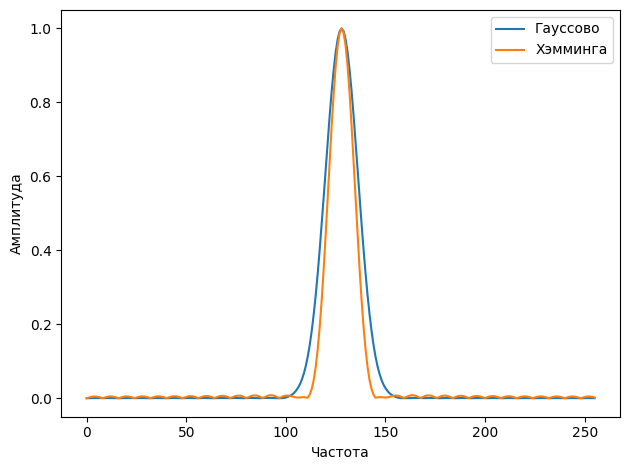

In [30]:
# Сравним амплитудные спектры.

plt.plot(np.abs(gaussian_fft), label='Гауссово')
plt.plot(np.abs(hamming_fft), label='Хэмминга')
decorate(xlabel='Частота', ylabel='Амплитуда')
plt.legend()


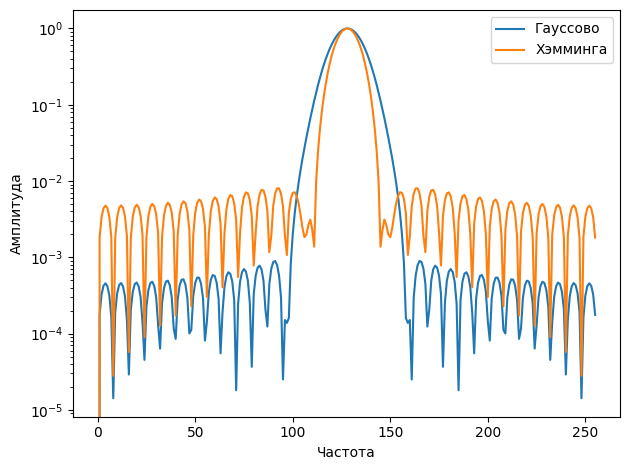

In [31]:
# То же самое в логарифмическом масштабе по оси y.

plt.plot(np.abs(gaussian_fft), label='Гауссово')
plt.plot(np.abs(hamming_fft), label='Хэмминга')
decorate(xlabel='Частота', ylabel='Амплитуда', yscale='log')
plt.legend()


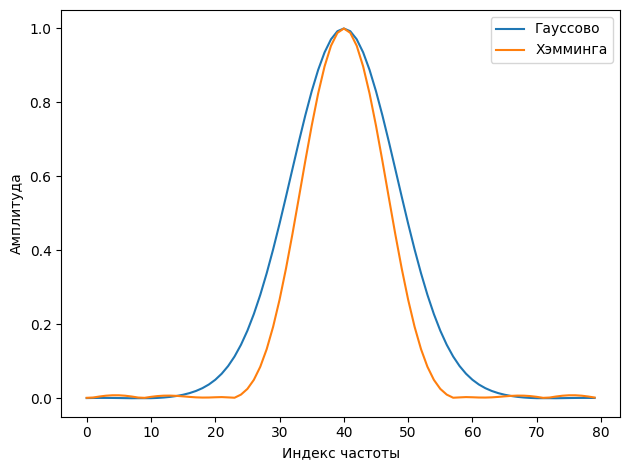

In [32]:
# Посмотрим ближе на центральную часть спектра.

mid = N // 2
window = 40

plt.plot(np.abs(gaussian_fft)[mid-window:mid+window], label='Гауссово')
plt.plot(np.abs(hamming_fft)[mid-window:mid+window], label='Хэмминга')
decorate(xlabel='Индекс частоты', ylabel='Амплитуда')
plt.legend()

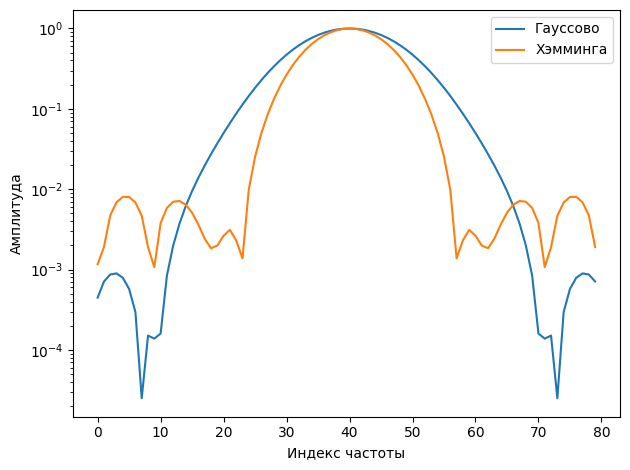

In [33]:
# И на боковые лепестки в логарифмическом масштабе.

plt.plot(np.abs(gaussian_fft)[mid-window:mid+window], label='Гауссово')
plt.plot(np.abs(hamming_fft)[mid-window:mid+window], label='Хэмминга')
decorate(xlabel='Индекс частоты', ylabel='Амплитуда', yscale='log')
plt.legend()

In [34]:
# Сделаем функцию, чтобы попробовать разные размеры окон.

def plot_window_dfts(M, std):
    gaussian = scipy.signal.windows.gaussian(M=M, std=std)
    hamming = np.hamming(M)
    
    gaussian /= sum(gaussian)
    hamming /= sum(hamming)
    
    N = 8 * M
    
    gaussian_pad = np.zeros(N)
    gaussian_pad[:M] = gaussian
    
    hamming_pad = np.zeros(N)
    hamming_pad[:M] = hamming
    
    gaussian_fft = np.roll(np.fft.fft(gaussian_pad), N//2)
    hamming_fft = np.roll(np.fft.fft(hamming_pad), N//2)
    
    plt.figure(figsize=(10, 4))
    
    plt.subplot(1, 2, 1)
    plt.plot(gaussian, label='Гауссово')
    plt.plot(hamming, label='Хэмминга')
    decorate(xlabel='Индекс')
    plt.legend()
    
    plt.subplot(1, 2, 2)
    plt.plot(np.abs(gaussian_fft), label='Гауссово')
    plt.plot(np.abs(hamming_fft), label='Хэмминга')
    decorate(xlabel='Частота', yscale='log')
    plt.legend()
    
    plt.show()

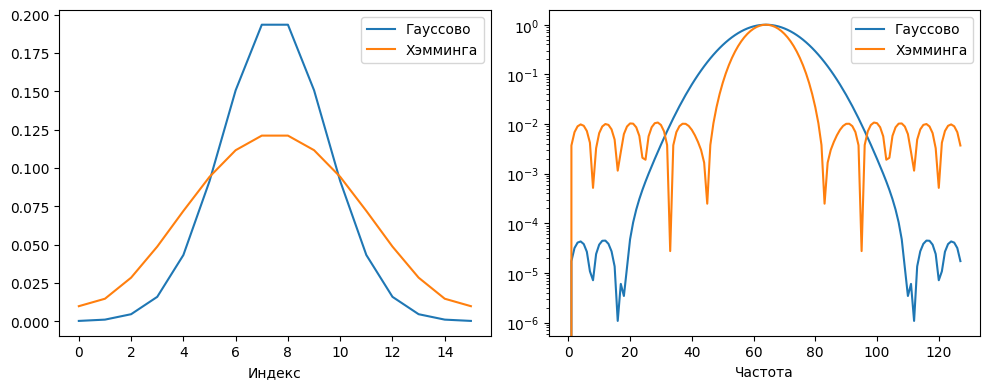

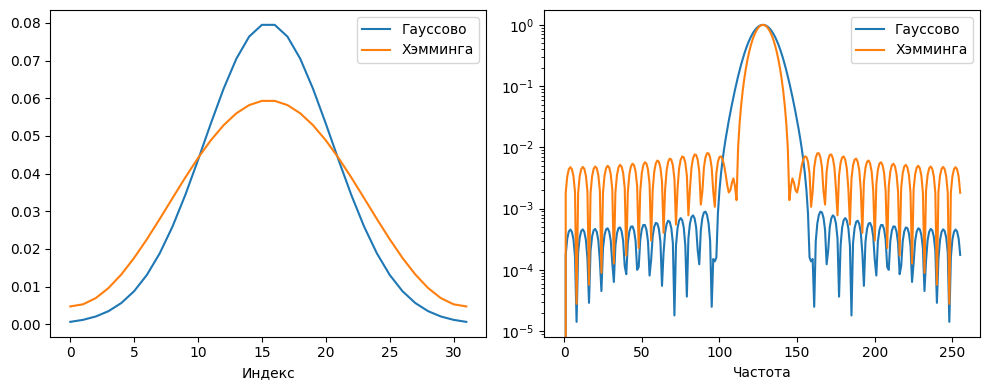

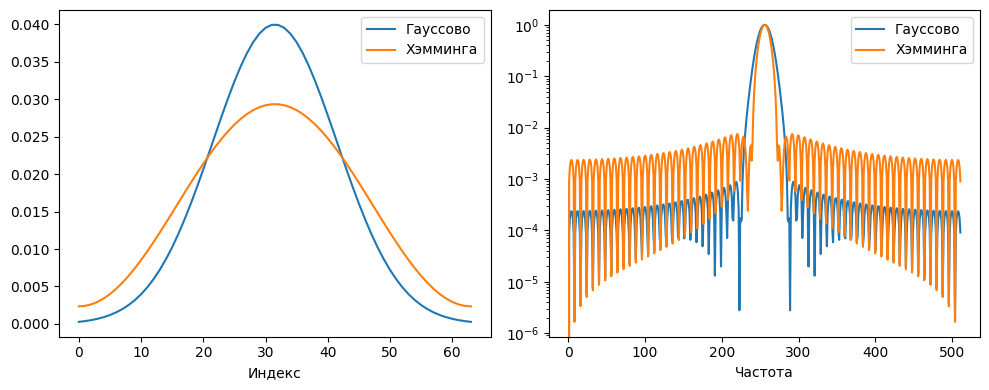

In [35]:
# Попробуем несколько размеров.

plot_window_dfts(M=16, std=2)
plot_window_dfts(M=32, std=5)
plot_window_dfts(M=64, std=10)

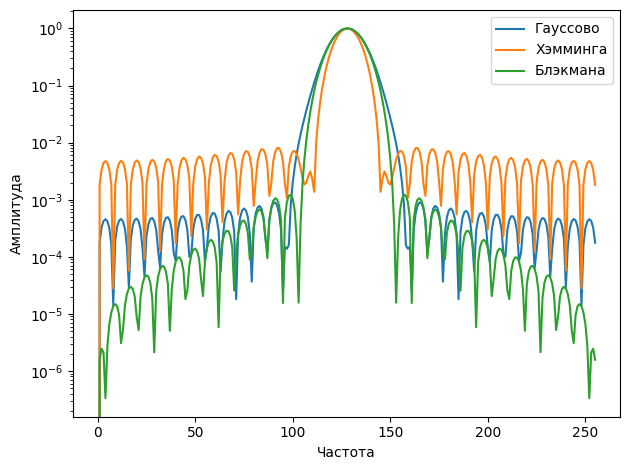

In [36]:
# Можно добавить еще одно окно для сравнения.

blackman = np.blackman(M)
blackman /= sum(blackman)

blackman_pad = np.zeros(N)
blackman_pad[:M] = blackman

blackman_fft = np.roll(np.fft.fft(blackman_pad), N//2)

plt.plot(np.abs(gaussian_fft), label='Гауссово')
plt.plot(np.abs(hamming_fft), label='Хэмминга')
plt.plot(np.abs(blackman_fft), label='Блэкмана')
decorate(xlabel='Частота', ylabel='Амплитуда', yscale='log')
plt.legend()

In [37]:
# Выводы:
# 1. ДПФ окон позволяет увидеть компромисс между шириной главного лепестка
#    и уровнем боковых лепестков.
# 2. У окна Хэмминга боковые лепестки обычно подавлены лучше,
#    чем у простого прямоугольного окна.
# 3. У гауссова окна спектр более гладкий, без резких переходов.
# 4. Для фильтра НЧ обычно лучше окно с меньшими боковыми лепестками,
#    потому что оно слабее пропускает лишние высокочастотные компоненты.
# 5. На практике гауссово и Хэмминга оба подходят, но окно Хэмминга
#    часто оказывается предпочтительнее как компромиссный НЧ-фильтр.